# COSC102 Assignment 3 - Comparing the Performance of Machine Learning Approaches for Activity Classification

**Authors:** 

This notebook analyses IMU data and classifies physical activities using K-Nearest Neighbours, Support Vector Classification, and Random Forest. The workflow includes data alignment, feature extraction, hyperparameter tuning, model evaluation, and comparison.

In [1]:
# Setup 

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from visualizations import (
    plot_confusion_matrix_comparison,
    plot_hyperparameter_comparison,
    plot_activity_alignment
)

from preprocessing import (
    load_imu_data,
    load_annotations,
    align_annotations_to_imu,
    window_features,
    get_features_and_labels,
    check_class_balance,
    get_cv_splitter,
)

In [2]:
# Align IMU data with annotations:

imu_df = load_imu_data("a3_imu_data.csv")
annotations_df = load_annotations("a3_activity_annotations.csv")

labelled_df = align_annotations_to_imu(imu_df, annotations_df)
feature_df = window_features(labelled_df)

print("Labelled data shape:", labelled_df.shape)
print("Time range:")
print(labelled_df["timestamp"].min())
print(labelled_df["timestamp"].max())
print("\nClass counts:")
print(labelled_df["label"].value_counts())
labelled_df.head()

Labelled data shape: (69350, 8)
Time range:
1598240221.0
1598240932.0

Class counts:
label
Jogging      19496
Walking      19341
Side-Step    11403
Running      10218
Standing      8892
Name: count, dtype: int64


,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,label
0,1.598240e+09,-2780,4694,-274,1015,2532,-982,Walking
1,1.598240e+09,-2804,4668,124,1301,2770,-881,Walking
2,1.598240e+09,-1900,4644,368,930,2811,-650,Walking
3,1.598240e+09,-1314,3832,-218,1068,2590,-466,Walking
4,1.598240e+09,-1694,2664,-1232,1283,987,-105,Walking


## Data Alignment

Raw IMU recording contains readings at the start and end that is not covered by the video. Activity transitions in the video annotations were
compared with changes in the accelerometer signal. This showed that the video begins approximately 8 seconds after the start of IMU recording. IMU data was therefore aligned to the video and trimmed to 711 second period covered by the video. The plot below is used as a sanity check that the activity transitions match changes in the IMU data.

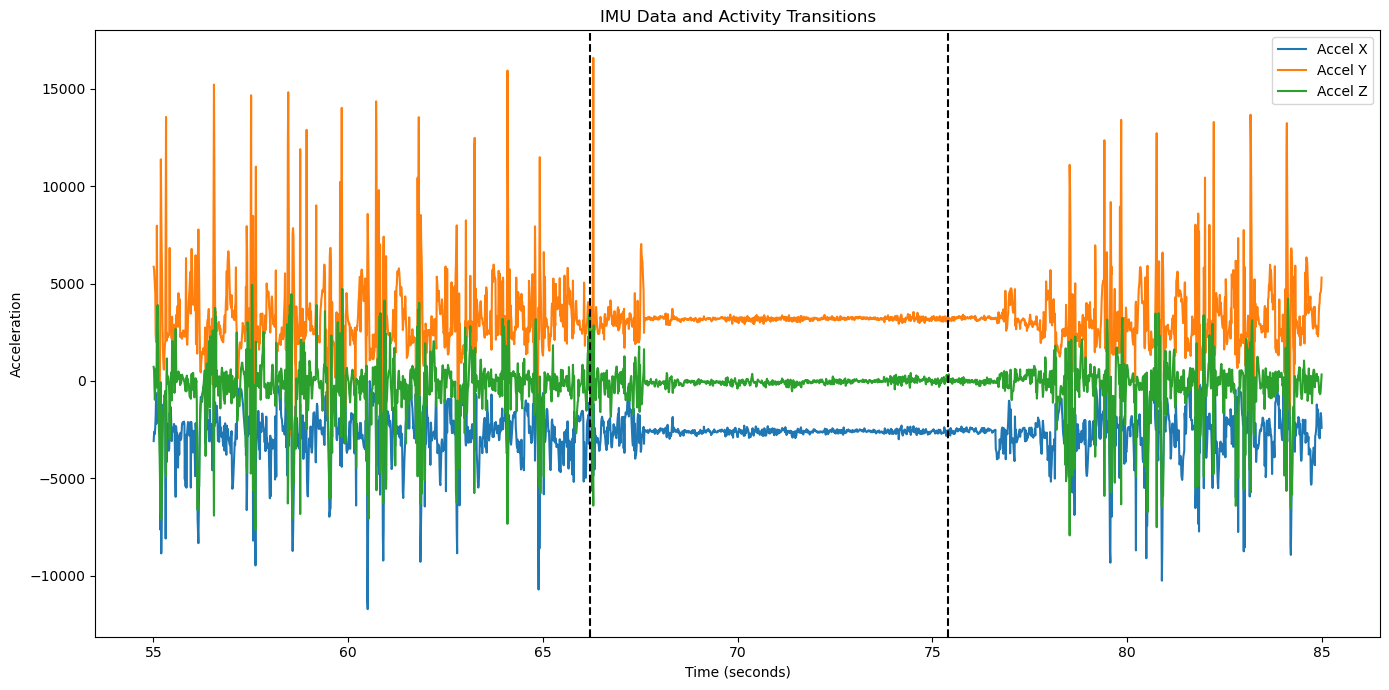

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'IMU Data and Activity Transitions'}, xlabel='Time (seconds)', ylabel='Acceleration'>)

In [3]:
plot_activity_alignment(
    labelled_df,
    annotations_df,
    start_sec=55,
    end_sec=85
)

## Feature Engineering

The IMU data was divided into 1-second windows. For each accelerometer and gyroscope axis, the mean, minimum, and maximum values was calculated. Also, SMA and average intensity features were included, producing 21 input features for each window.

In [4]:
# Feature Engineering

X, y = get_features_and_labels(
    imu_path="a3_imu_data.csv",
    annotations_path="a3_activity_annotations.csv",
    window_size_sec=1
)

# print and head for preview
print("X shape:", X.shape)
print("\nClass balance:")
print(check_class_balance(y))
print(f"Feature matrix: {X.shape}")
X.head()

X shape: (709, 21)

Class balance:
label
Jogging      201
Walking      197
Side-Step    115
Running      105
Standing      91
Name: count, dtype: int64
Feature matrix: (709, 21)


,accel_x_mean,accel_x_min,accel_x_max,accel_y_mean,accel_y_min,accel_y_max,accel_z_mean,accel_z_min,accel_z_max,gyro_x_mean,...,gyro_x_max,gyro_y_mean,gyro_y_min,gyro_y_max,gyro_z_mean,gyro_z_min,gyro_z_max,accel_sma,gyro_sma,avg_intensity
0,-2509.540000,-3742,-1314,2991.060000,1692,4694,-858.640000,-3510,368,109.340000,...,1789,397.500000,-86,2811,-186.320000,-1086,217,6370.800000,1133.100000,4134.507007
1,-2703.360000,-4628,-650,3299.400000,1786,6784,-318.740000,-3576,994,188.040000,...,2548,-120.140000,-2889,3042,-54.690000,-1814,895,6675.900000,2620.390000,4477.602472
2,-2706.400000,-11210,32,3284.920000,-1244,12562,-480.520000,-7110,2822,24.890000,...,2076,-203.910000,-4045,3959,41.650000,-1564,1289,7095.000000,3184.830000,4712.420777
3,-2678.989011,-8976,-592,2999.670330,-1376,12910,-464.637363,-6478,3198,-261.120879,...,1857,-471.725275,-4256,2942,120.879121,-1381,1110,6868.483516,2798.252747,4528.468334
4,-2692.775510,-9162,394,2993.918367,-720,13320,-468.265306,-6962,3450,-188.602041,...,2331,-327.642857,-3419,2573,-48.265306,-1808,1482,6907.897959,3190.979592,4527.485102


### Feature Visualization
haha idk

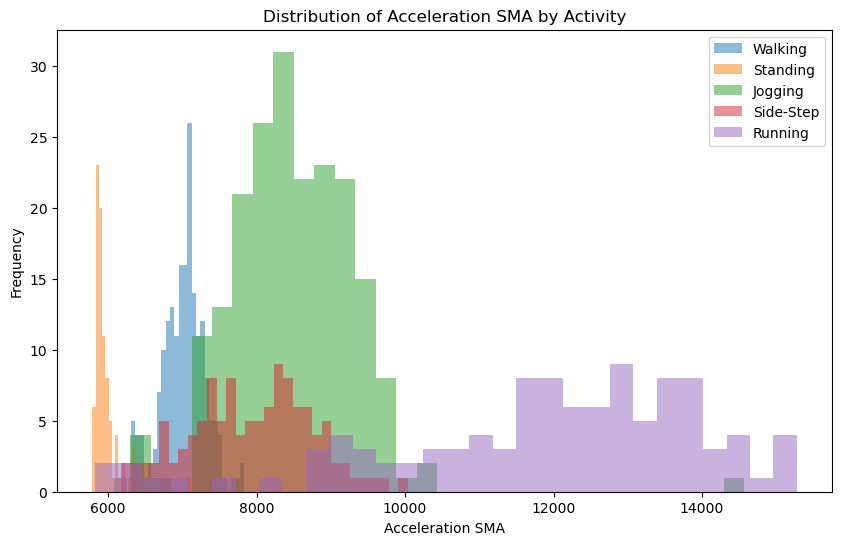

In [20]:
plt.figure(figsize=(10, 6))
for activity in feature_df["label"].unique():
    activity_data = feature_df[feature_df["label"] == activity]
    plt.hist(
        activity_data["accel_sma"],
        bins=30,
        alpha=0.5,
        label=activity
    )

plt.xlabel("Acceleration SMA")
plt.ylabel("Frequency")
plt.title("Distribution of Acceleration SMA by Activity")
plt.legend()
plt.show()

## Classification Algorithms and Hyperparameter Tuning

All three algorithms were tuned using GridSearchCV with the same stratified K-fold splitter. This ensures that the models are trained and evaluated using consistent folds for comparison. The training functions for each classifier are stored in theirrespective python files, while the results are presented below.

In [6]:
# Define cv variable so all algorithms run on identical data
cv = get_cv_splitter()

### K-NN algorithm

In [7]:
from knn import train_knn, knn_summary

knn_results = train_knn(X, y, cv=cv)
knn_summary_results = knn_summary(knn_results, X, y, cv=cv)

Best parameters: {'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Best CV accuracy: 0.941

Clasification Report summary: 
              precision    recall  f1-score   support

     Jogging       0.93      0.97      0.95       201
     Running       0.99      0.81      0.89       105
   Side-Step       0.97      0.94      0.96       115
    Standing       0.87      0.95      0.91        91
     Walking       0.95      0.98      0.96       197

    accuracy                           0.94       709
   macro avg       0.94      0.93      0.93       709
weighted avg       0.94      0.94      0.94       709

Confusion Matrix: 
[[195   0   1   3   2]
 [ 13  85   1   4   2]
 [  1   1 108   2   3]
 [  0   0   1  86   4]
 [  0   0   0   4 193]]


### SVC algorithm

In [8]:
from svc import run_svc

svc_grid, svc_results = run_svc(X, y, cv=cv)

Best parameters: {'svc__C': 100, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
Best CV accuracy: 0.955

Classification Report:
              precision    recall  f1-score   support

     Jogging       0.99      0.98      0.98       201
     Running       0.99      0.92      0.96       105
   Side-Step       0.98      0.94      0.96       115
    Standing       0.86      0.93      0.89        91
     Walking       0.94      0.97      0.95       197

    accuracy                           0.95       709
   macro avg       0.95      0.95      0.95       709
weighted avg       0.96      0.95      0.96       709

Confusion Matrix:
[[196   0   0   3   2]
 [  2  97   1   4   1]
 [  0   1 108   2   4]
 [  0   0   0  85   6]
 [  0   0   1   5 191]]


The best SVC model used an RBF kernel with C=100 and gamma=0.001. It achieved a cross-validation accuracy of 0.955. Performance was consistent across the activity classes, including Standing, which achieved a recall of 0.93.

### Random Forest algorithm

In [9]:
from rforest import train_rforest, rforest_summary

rforest_results = train_rforest(X, y, cv=cv)
rforest_summary_results = rforest_summary(rforest_results, X, y, cv=cv)

Best parameters: {'rforest__max_leaf_nodes': 32, 'rforest__n_estimators': 500}
        Best CV accuracy: 0.946

Classification Report Summary: 
              precision    recall  f1-score   support

     Jogging       0.99      0.97      0.98       201
     Running       0.99      0.90      0.94       105
   Side-Step       0.95      0.92      0.94       115
    Standing       0.87      0.91      0.89        91
     Walking       0.91      0.97      0.94       197

    accuracy                           0.94       709
   macro avg       0.94      0.93      0.94       709
weighted avg       0.95      0.94      0.95       709

        Confusion Matrix: 
        [[195   0   0   3   3]
 [  1  94   5   2   3]
 [  0   1 106   2   6]
 [  0   0   0  83   8]
 [  0   0   0   5 192]]


## Model Evaluation and Visualizations

Visualizations live in visualizations.py and are called here for each classification algorithm.

In [10]:
#Setup for visualization section

# defining consistent label order:
activity_labels = sorted(y.unique())

knn_pred = knn_summary_results["predictions"]
svc_pred = svc_results["predictions"]
rforest_pred = rforest_summary_results["predictions"]

knn_score = knn_results["best_score"]
rforest_score = rforest_results["best_score"]
svc_score = svc_grid.best_score_

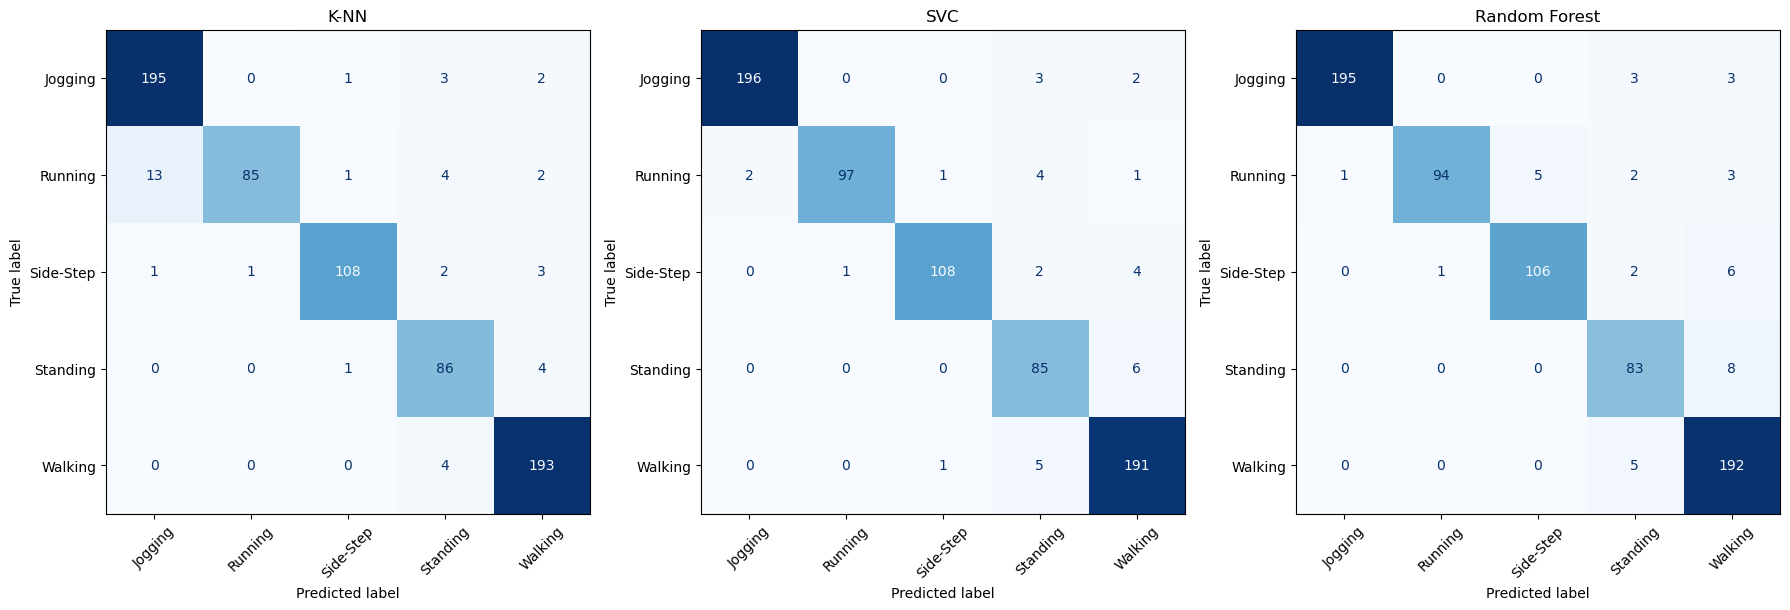

In [11]:
# Confusion matrices

plot_confusion_matrix_comparison(
    predictions_by_model={
        "K-NN": knn_pred,
        "SVC": svc_pred,
        "Random Forest": rforest_pred,
    },
    y_true=y,
    labels=activity_labels
)

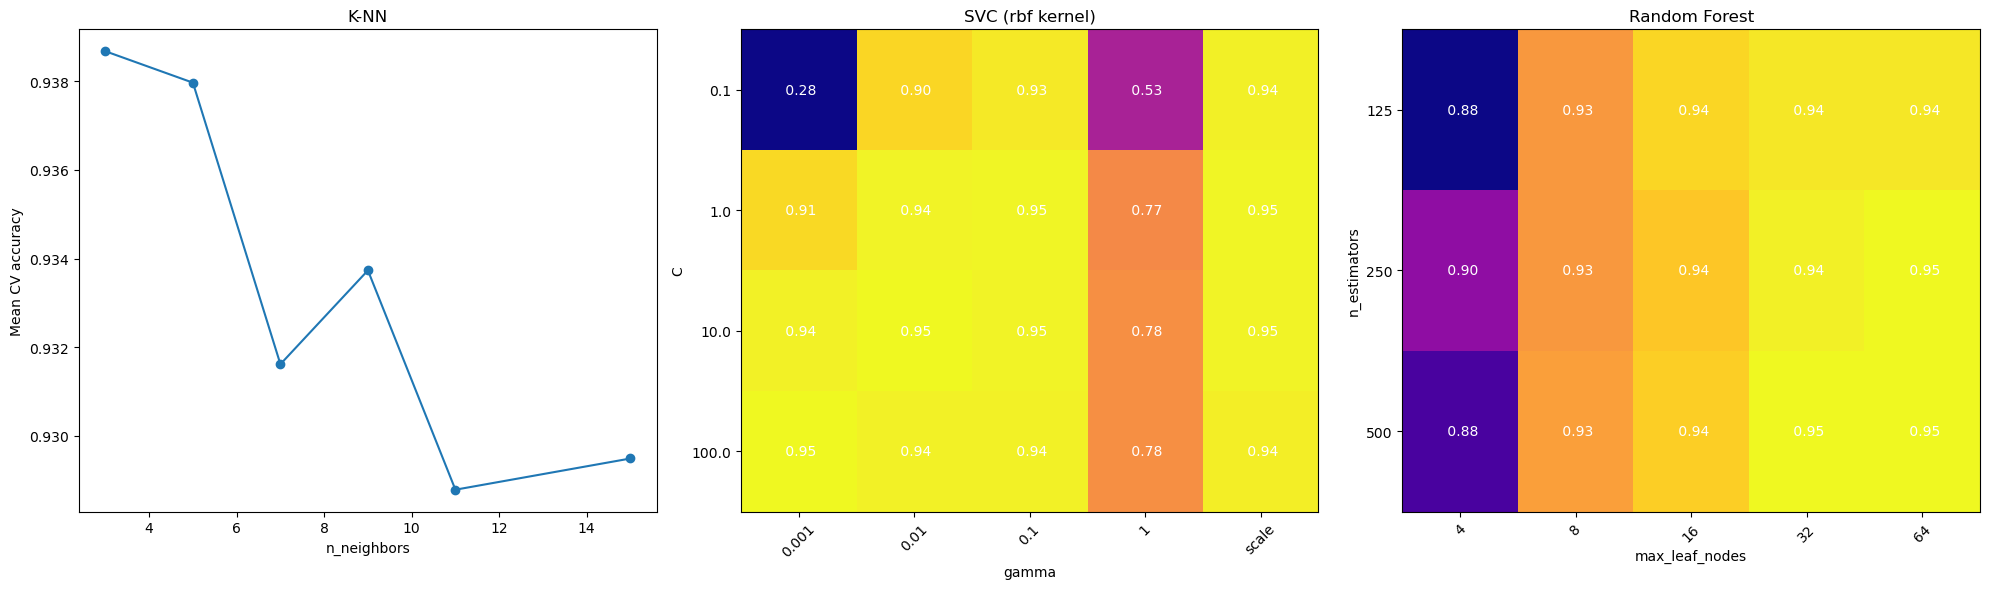

In [12]:
# Hyperparameter Comparison

plot_hyperparameter_comparison(
    knn_grid=knn_results["grid"],
    svc_grid=svc_grid,
    rforest_grid=rforest_results["grid"]
)